In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from matplotlib.colors import ListedColormap
from sklearn.manifold import TSNE
import numpy as np

In [21]:
file = "norm_6_no_outliers.csv"

In [22]:
df = pd.read_csv(file)
labels = df.columns.to_list()
if 'label' in labels:
    X = df.drop(columns=['label']).values
else:
    X = df.values

In [23]:
if file == "dvi_dim_lbl.csv":
   X_tsne = np.array(X)
elif file == "norm_full_no_outliers.csv":
   perp = 50
   learn_r = 200
   early_ex = 24
elif file == "norm_6_no_outliers.csv":
   perp = 50
   learn_r = 50
   early_ex = 12

In [26]:
dbscan = DBSCAN(eps=0.1, min_samples=5, metric="euclidean")
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Rasta klasterių (be triukšmo): {n_clusters}")

Rasta klasterių (be triukšmo): 12


In [27]:
if file != "dvi_dim_lbl.csv":
    tsne = TSNE(
        n_components=2,         # sumažiname duomenų dimensijų skaičių iki 2
        perplexity=perp,          # kiek artimiausių kaimynų laikoma reikšmingais
        learning_rate=learn_r,      # nustato, kokio dydžio korekcijos taikomos kiekviename iteracijos žingsnyje
        max_iter=1000,            # iteracijų skaičius: kiek gradientinio nusileidimo žingsnių atliekama minimizuojant klaidą
        early_exaggeration=early_ex,# padeda atskirti klasterius ir išvengti lokalių minimumų
        metric="euclidean",     # atstumo metrika pradinėje erdvėje
        random_state=67,        # kad rezultatai būtų atkuriami (užtikrina tą pačią pradinę taškų padėtį)
        init="pca"              # pradinė taškų pozicija nustatoma PCA pagrindu (stabiliau nei random)
    )

    X_tsne = tsne.fit_transform(X)

/var/folders/8m/2mjbvkv91xx273zl_4n42rsr0000gn/T/ipykernel_9684/1854948387.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', max(1, n_clusters))


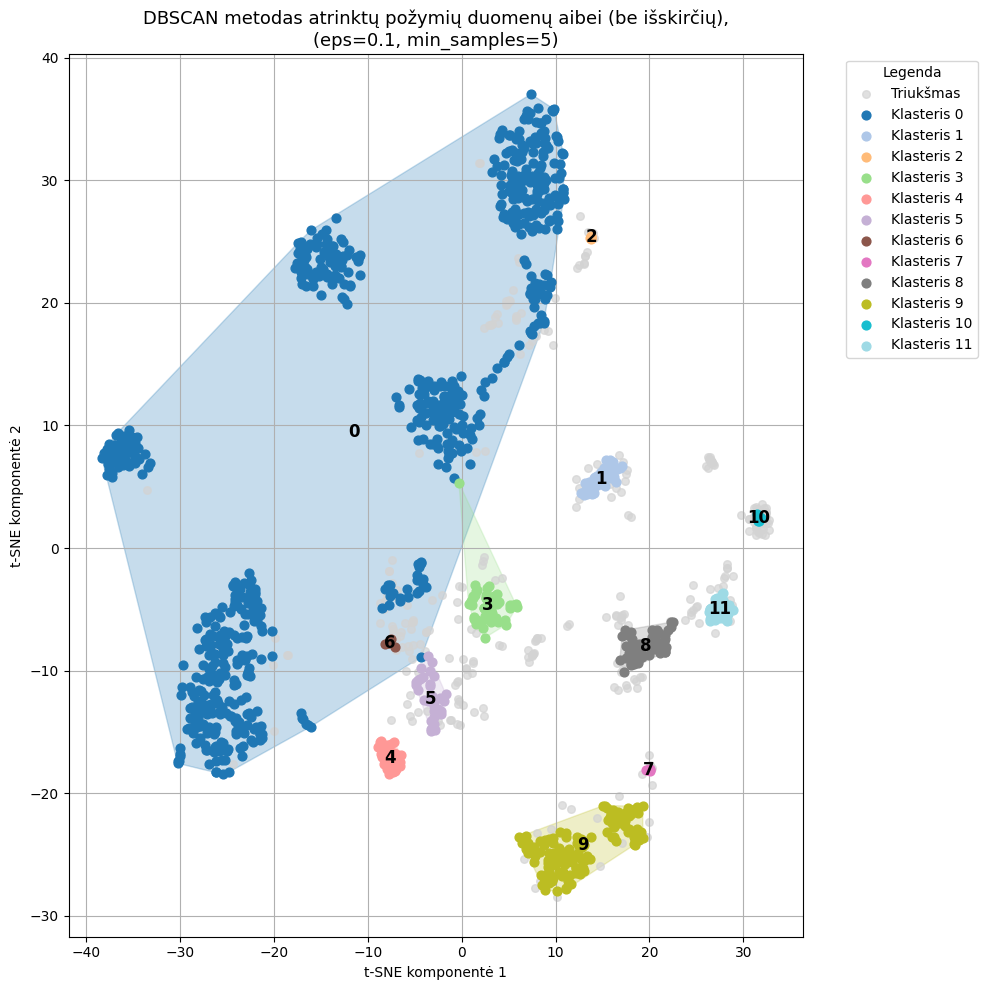

In [30]:
from scipy.spatial import ConvexHull

plt.figure(figsize=(10, 10))

unique_labels = sorted(set(labels))
cluster_ids = [l for l in unique_labels if l != -1]
n_clusters = len(cluster_ids)

# Spalvos tik klasteriams (be -1). Pasirink "tab20" (be pilkų tonų).
# Jei klasterių daug, gali rinktis 'hsv' arba 'turbo'.
cmap = plt.cm.get_cmap('tab20', max(1, n_clusters))
label_to_color = {lab: cmap(i) for i, lab in enumerate(cluster_ids)}

# --- Triukšmas ---
noise_mask = (labels == -1)
if np.any(noise_mask):
    plt.scatter(
        X_tsne[noise_mask, 0],
        X_tsne[noise_mask, 1],
        s=30,
        c="lightgrey",
        label="Triukšmas",
        zorder=1,
        alpha=0.7
    )

# --- Klasteriai ---
for lab in cluster_ids:
    cl_mask = (labels == lab)
    cluster_points = X_tsne[cl_mask]
    color = label_to_color[lab]

    plt.scatter(
        cluster_points[:, 0],
        cluster_points[:, 1],
        s=40,
        color=color,
        label=f"Klasteris {lab}",
        zorder=2
    )

    if cluster_points.shape[0] >= 3:
        hull = ConvexHull(cluster_points)
        hull_pts = cluster_points[hull.vertices]
        plt.fill(
            hull_pts[:, 0], hull_pts[:, 1],
            alpha=0.25,
            color=color,
            zorder=0
        )
        centroid = cluster_points.mean(axis=0)
        plt.text(
            centroid[0], centroid[1], str(lab),
            fontsize=12, fontweight="bold",
            ha="center", va="center", color="black"
        )

plt.title("DBSCAN metodas atrinktų požymių duomenų aibei (be išskirčių),\n(eps=0.1, min_samples=5)", fontsize=13)
plt.xlabel("t-SNE komponentė 1")
plt.ylabel("t-SNE komponentė 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Legenda")
plt.grid(True)
plt.tight_layout()
plt.show()



--- Dažnių lentelė (klasteriai × klasės) ---
true_label    0    1    2
cluster                  
-1           69   52  156
 0          382  316    0
 1           41    1    2
 2            6    0    0
 3            0   12   37
 4            0   37    0
 5            0   35    0
 6            0    4    1
 7            0    0    6
 8            0    0   54
 9            0    0  131
 10           0    0    6
 11           0    0   33

--- Procentai (%) klasterio viduje ---
true_label       0       1       2
cluster                           
-1           24.91   18.77   56.32
 0           54.73   45.27    0.00
 1           93.18    2.27    4.55
 2          100.00    0.00    0.00
 3            0.00   24.49   75.51
 4            0.00  100.00    0.00
 5            0.00  100.00    0.00
 6            0.00   80.00   20.00
 7            0.00    0.00  100.00
 8            0.00    0.00  100.00
 9            0.00    0.00  100.00
 10           0.00    0.00  100.00
 11           0.00    0.00  100.00

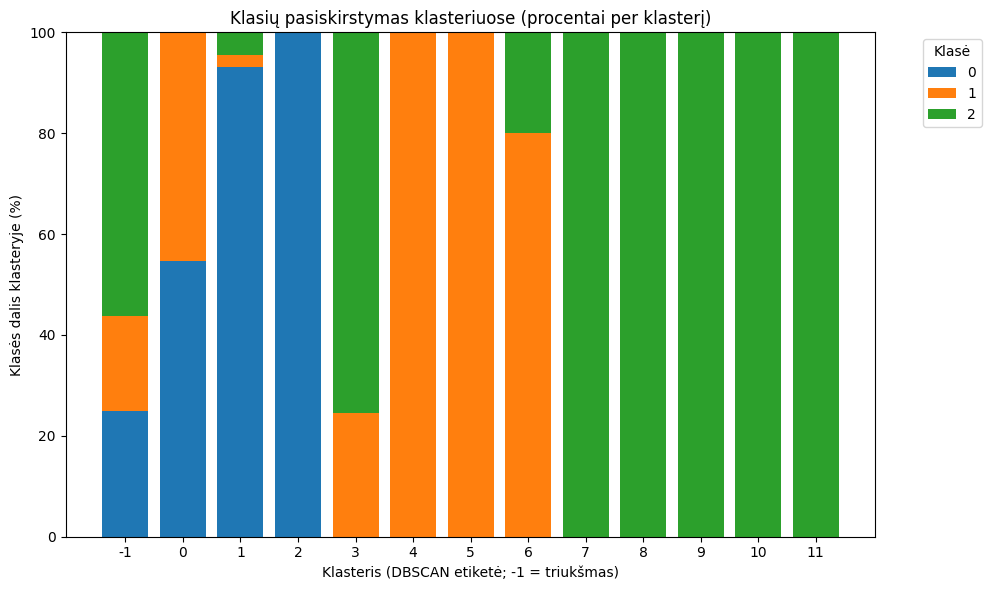

In [29]:
# %% ---- Klasių pasiskirstymas klasteriuose (su metrika)
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from math import log2

# Patikriname ar yra "label" (tikros klasės)
has_true = 'label' in df.columns

# Paruošiam analizės duomenis
data_for_summary = pd.DataFrame({
    'cluster': labels
})
if has_true:
    data_for_summary['true_label'] = df['label'].values

# 1) Skaitinės dažnių lentelės
if has_true:
    counts = pd.crosstab(index=data_for_summary['cluster'],
                         columns=data_for_summary['true_label'],
                         dropna=False)
else:
    # be 'label' parodome tik klasterių dydžius
    counts = data_for_summary['cluster'].value_counts(dropna=False).rename('count').to_frame()

print("\n--- Dažnių lentelė (klasteriai × klasės) ---")
print(counts)

# 2) Procentai klasterio viduje (eilutė sumuojasi iki 100 %)
if has_true:
    row_sums = counts.sum(axis=1).replace(0, np.nan)
    perc = (counts.div(row_sums, axis=0) * 100).fillna(0).round(2)
    print("\n--- Procentai (%) klasterio viduje ---")
    print(perc)

# 3) Kiek triukšmo taškų
n_noise = int((data_for_summary['cluster'] == -1).sum())
n_total = len(data_for_summary)
print(f"\nTriukšmo taškų (-1) skaičius: {n_noise} iš {n_total} ({n_noise / max(1, n_total) * 100:.1f} %)")

# 4) Daugumos klasė, purity ir entropija kiekvienam klasteriui
def entropy(counts_row):
    total = counts_row.sum()
    if total == 0:
        return 0.0
    probs = counts_row[counts_row > 0] / total
    return -float(np.sum(probs * np.log2(probs)))

summary_rows = []
if has_true:
    for cl in sorted(counts.index):
        row = counts.loc[cl]
        total = int(row.sum())
        if total == 0:
            summary_rows.append({
                'cluster': cl, 'size': 0, 'majority_class': None,
                'purity': np.nan, 'entropy_bits': np.nan
            })
            continue
        maj_class = row.idxmax()
        purity = row.max() / total
        ent = entropy(row)
        summary_rows.append({
            'cluster': cl,
            'size': total,
            'majority_class': maj_class,
            'purity': round(purity, 3),
            'entropy_bits': round(ent, 3)
        })

    cluster_quality = pd.DataFrame(summary_rows).sort_values(['cluster'])
    print("\n--- Klasterių kokybės santrauka ---")
    print(cluster_quality)

# 5) Bendros suderinamumo metrikos (jei yra tikros etiketės)
if has_true:
    # Pastaba: ARI/NMI skaičiuojamos įskaitant triukšmą (-1); tai OK
    ari = adjusted_rand_score(df['label'].values, labels)
    nmi = normalized_mutual_info_score(df['label'].values, labels)
    print(f"\nARI: {ari:.4f}")
    print(f"NMI: {nmi:.4f}")

# 6) Vizualizacija: sukrauti stulpeliai (procentai per klasterį)
if has_true:
    import matplotlib.pyplot as plt

    # Rūšiuojame klasterius pagal identifikatorių; triukšmą laikome pirmu
    ordered_idx = sorted(perc.index, key=lambda x: (x != -1, x))
    perc_plot = perc.loc[ordered_idx]

    plt.figure(figsize=(10, 6))
    bottom = np.zeros(len(perc_plot))
    x = np.arange(len(perc_plot))
    class_order = perc_plot.columns.tolist()
    for cls in class_order:
        vals = perc_plot[cls].values
        plt.bar(x, vals, bottom=bottom, label=str(cls))
        bottom += vals

    plt.xticks(x, [str(i) for i in perc_plot.index])
    plt.xlabel("Klasteris (DBSCAN etiketė; -1 = triukšmas)")
    plt.ylabel("Klasės dalis klasteryje (%)")
    plt.title("Klasių pasiskirstymas klasteriuose (procentai per klasterį)")
    plt.legend(title="Klasė", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
